First step in the data processing pipeline is merging the forecasts and oracle series

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tail_calibration.metrics import tail_calibration, tail_calibration_by_id, evaluate_models
from tail_calibration.flucast_utils import load_flusight_data, build_evaluation_df
from tail_calibration.plot_utils import (plot_tail_calibration, 
                                         plot_tail_calibration_by_id, 
                                         plot_tail_calibration_by_id_and_horizon, 
                                         plot_tail_miscalibration_by_horizon, 
                                         plot_wis_vs_tail)

forecast_names = ["UMass-flusion", "FluSight-ensemble", "FluSight-lop_norm", "MIGHTE-Nsemble", 
                  "UGA_flucast-INFLAenza", "CU-ensemble", "fjordhest-ensemble", "UGA_flucast-Copycat", 
                  "PSI-PROF", "MOBS-GLEAM_FLUH", "UVAFluX-Ensemble", "CMU-TimeSeries", 
                  "UMass-trends_ensemble", "CEPH-Rtrend_fluH", "FluSight-baseline", 
                  "UM-DeepOutbreak", "UVAFluX-Ensemble", "SigSci-TSENS", "UGA_flucast-INFLAenza"]

time_series, _, forecasts = load_flusight_data(filters={
    "forecasts": {
        "model_id": forecast_names,
        "horizon":  [0, 1, 2, 3],
        "target": ["wk inc flu hosp"], 
        "output_type": ["quantile"]
    }, 
    "time_series": {
        "target": ["wk inc flu hosp"]
    }
})

date_ranges = {
    ("2023-10-14", "2024-04-27"): "2024-04-27",
    ("2024-10-14", "2025-06-21"): "2025-07-23"
}

result = build_evaluation_df(forecasts, time_series, date_ranges)

Fetching FluSight data from S3...


## Tail Probabilistic Calibration

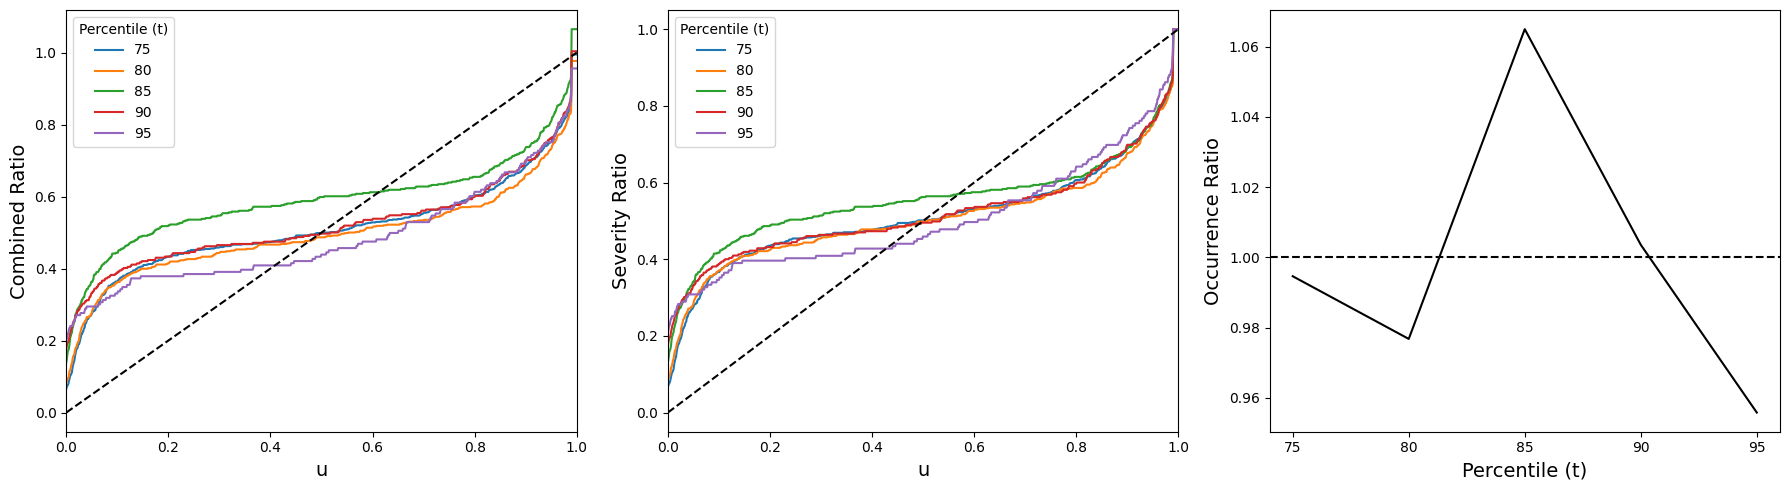

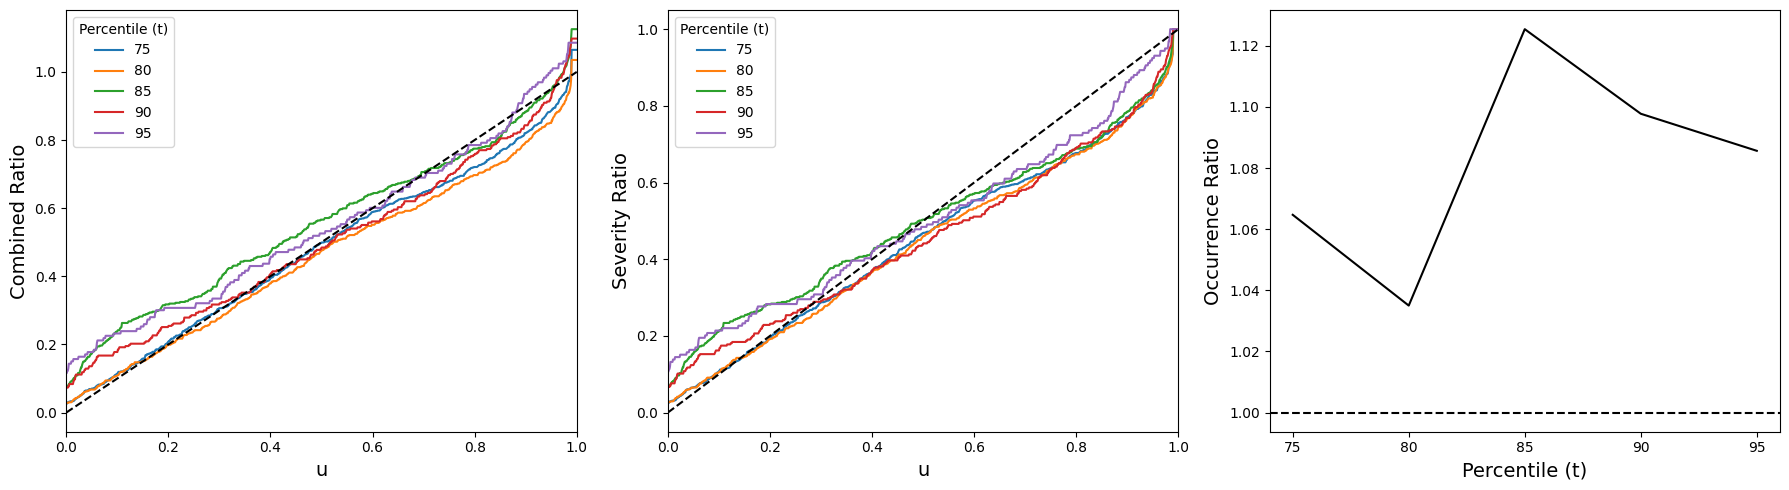

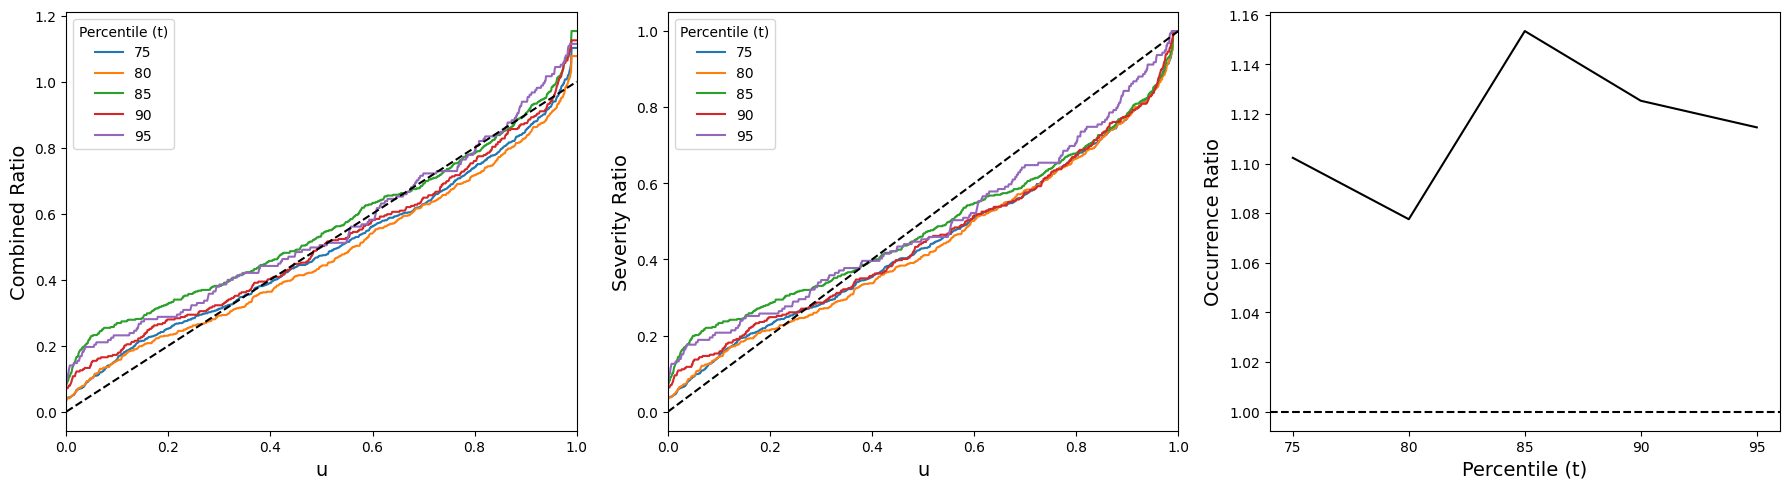

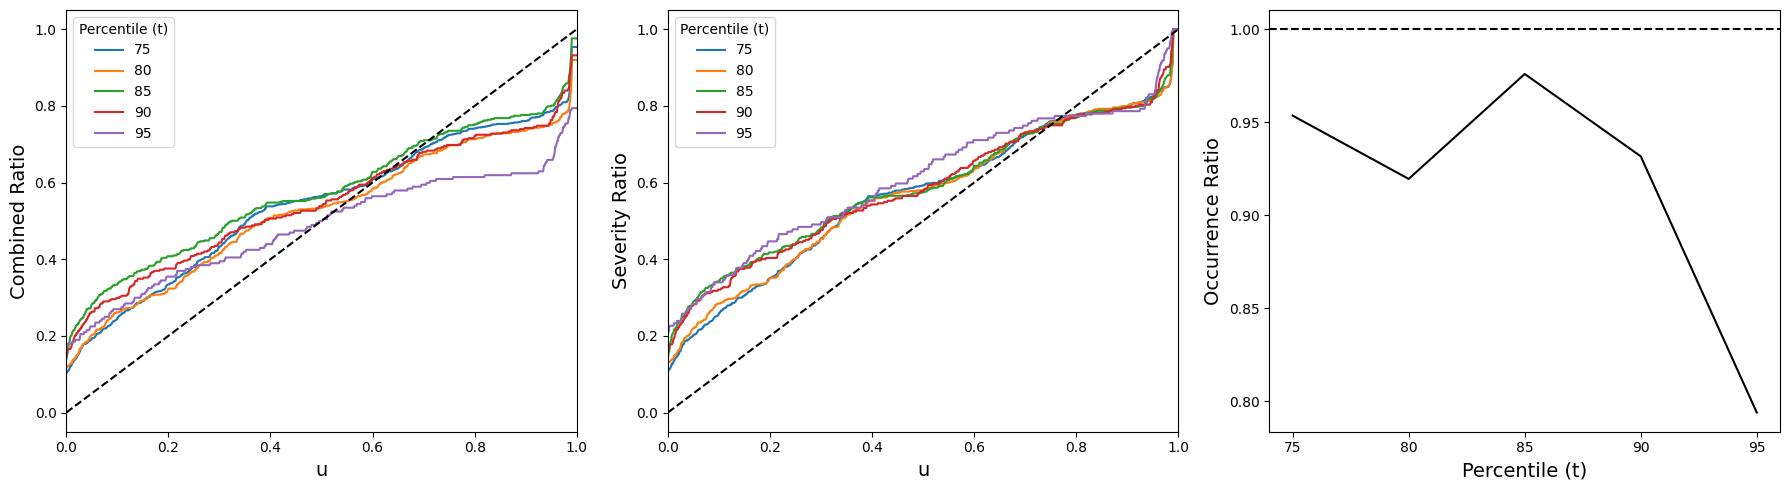

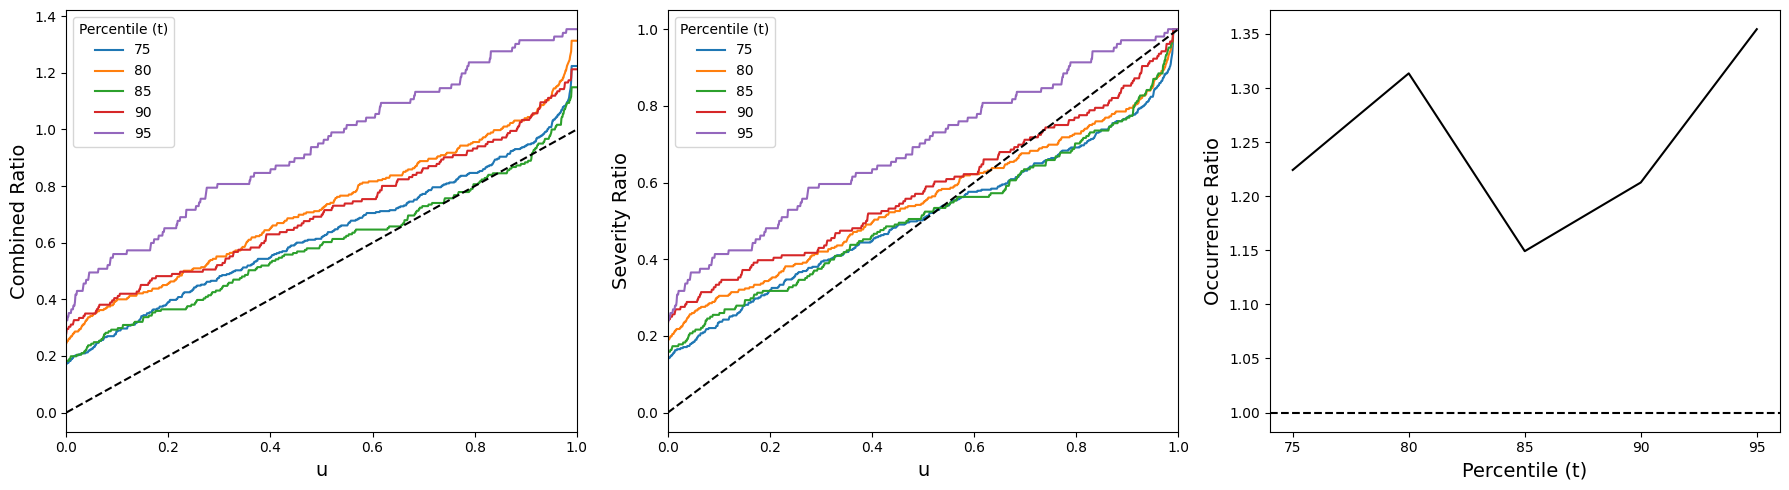

In [2]:
models = ['FluSight-baseline', 'FluSight-ensemble', "CMU-TimeSeries", 'UMass-flusion', "UM-DeepOutbreak", "Gatech-ensemble_prob"]
for model_id in models:
        mask = (
            (result["model_id"] == model_id)
            & (result["target"] == "wk inc flu hosp")
            & (result["horizon"] == 0)
        )
        if not mask.any():
            continue

        ePIT_map = tail_calibration(
            result[mask],
            id_col="location",
            oracle_col="observation",
            p=[75, 80, 85, 90, 95],
            randomized=True
        )

        fig = plot_tail_calibration(ePIT_map)
        fig.savefig(f'../images/diagnostics/model/tail_calibration_{model_id}.png', dpi=150, bbox_inches='tight')
        


## Tail Auto-Calibration

In [14]:
import pandas as pd

date_ranges = [
    ("2023-10-14", "2024-04-27"),
    ("2024-10-14", "2025-06-21"),
]

models = ['FluSight-ensemble', 'CMU-TimeSeries', 'UMass-flusion']

for model_id in models:
    for i, (start, end) in enumerate(date_ranges):
        mask = (
            (result["model_id"] == model_id)
            & (result["target"] == "wk inc flu hosp")
            & (result["horizon"] == 0)
            & (pd.to_datetime(result["target_end_date"]) >= pd.Timestamp(start))
            & (pd.to_datetime(result["target_end_date"]) <= pd.Timestamp(end))
        )

        if not mask.any():
            print(f"Skipping {model_id} period {i} ({start} to {end}): no data")
            continue

        try:
            ePIT_map = tail_calibration(
                result[mask],
                id_col="location",
                oracle_col="observation",
                p=[75, 80, 85, 90, 95],
                randomized=True
            )
        except AssertionError as e:
            print(f"Skipping {model_id} period {i} ({start} to {end}): {e}")
            continue

        fig = plot_tail_calibration(ePIT_map)
        fig.savefig(
            f'../images/diagnostics/model/tail_calibration_{model_id}_period{i}_{start}.png',
            dpi=150, bbox_inches='tight'
        )
        plt.close(fig)

## State-level Variation

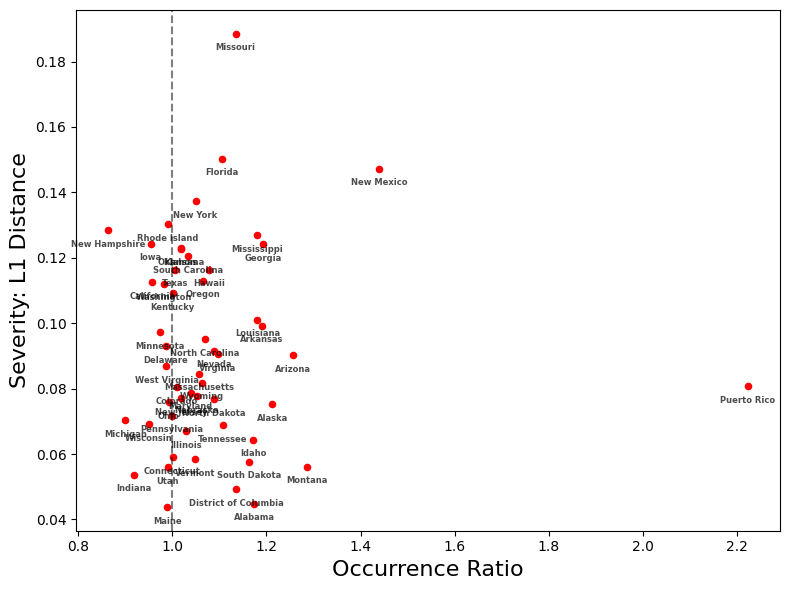

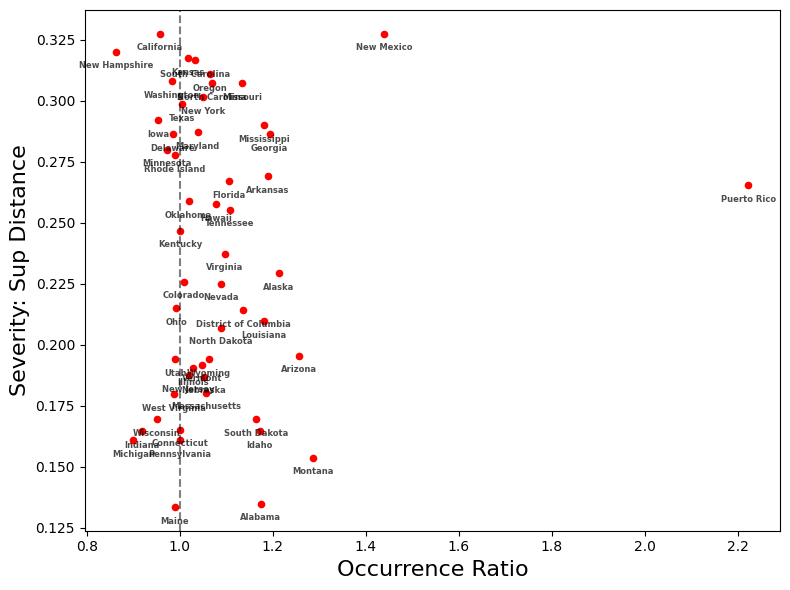

In [3]:
mask = (
    (result["model_id"] == "FluSight-ensemble") 
    & (result["target"] == "wk inc flu hosp") 
    & (result["horizon"] == 0)
    & (result["location_name"] != "US")
)

ePIT_by_state_map = tail_calibration_by_id(
    result[mask], 
    id_col="location_name", 
    oracle_col="observation", 
    p=[75], 
    randomized=True
)

fig_l1 = plot_tail_calibration_by_id(ePIT_by_state_map, percentile=75, severity_metric='l1')
fig_l1.savefig(
            f'../images/diagnostics/supplemental/tail_calibration_FluSight-ensemble_75_l1.png',
            dpi=150, bbox_inches='tight'
        )
fig_sup = plot_tail_calibration_by_id(ePIT_by_state_map, percentile=75, severity_metric='sup')
fig_sup.savefig(
            f'../images/diagnostics/supplemental/tail_calibration_FluSight-ensemble_75_sup.png',
            dpi=150, bbox_inches='tight'
        )
plt.show()

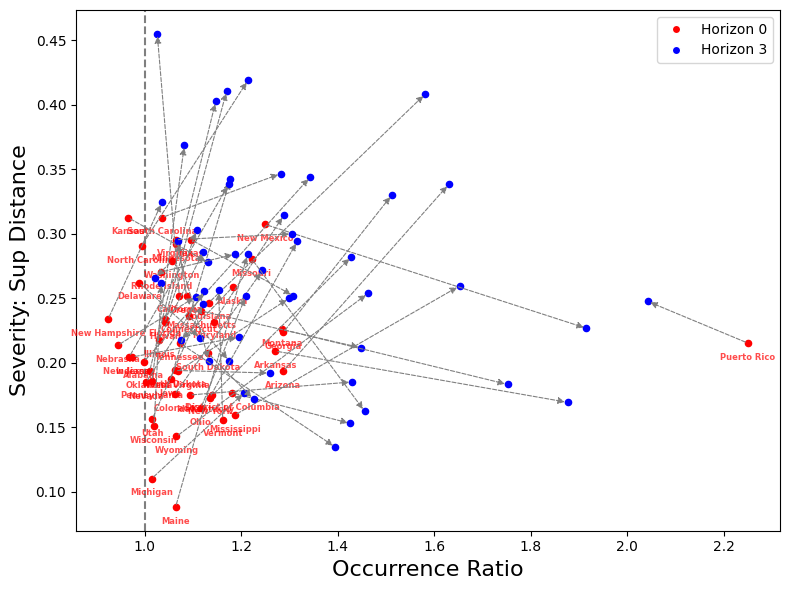

In [ ]:
mask = (
    (result["model_id"] == "FluSight-ensemble") 
    & (result["target"] == "wk inc flu hosp") 
    & (result["location_name"] != "US")
)

by_id_map_h0 = tail_calibration_by_id(
    result[mask & (result["horizon"] == 0)], 
    id_col="location_name", 
    oracle_col="observation", 
    p=[75], 
    randomized=True
)

by_id_map_h3 = tail_calibration_by_id(
    result[mask & (result["horizon"] == 3)], 
    id_col="location_name", 
    oracle_col="observation", 
    p=[75], 
    randomized=True
)

fig = plot_tail_calibration_by_id_and_horizon(
    by_id_map_h0, by_id_map_h3,
    percentile=75,
    horizons=("Horizon 0", "Horizon 3"),
    severity_metric="sup"
)

fig.savefig(
            f'../images/diagnostics/supplemental/tail_calibration_FluSight-ensemble_75_sup_h0_to_h3.png',
            dpi=150, bbox_inches='tight'
        )

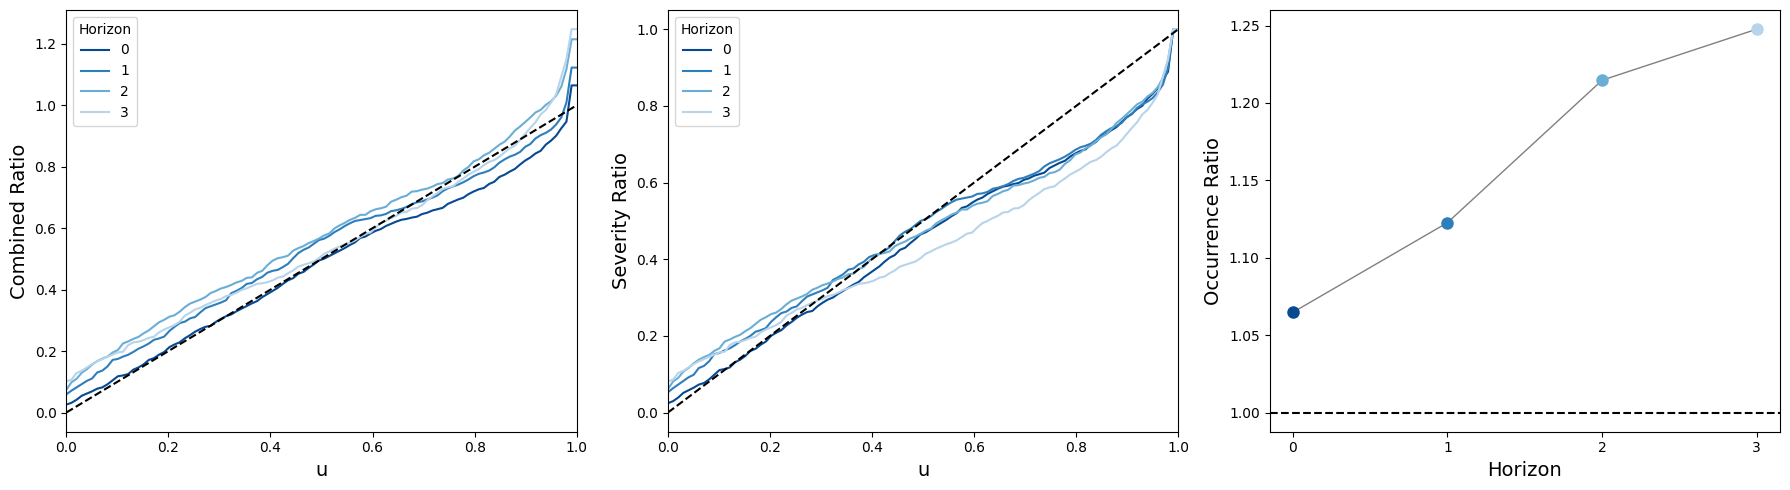

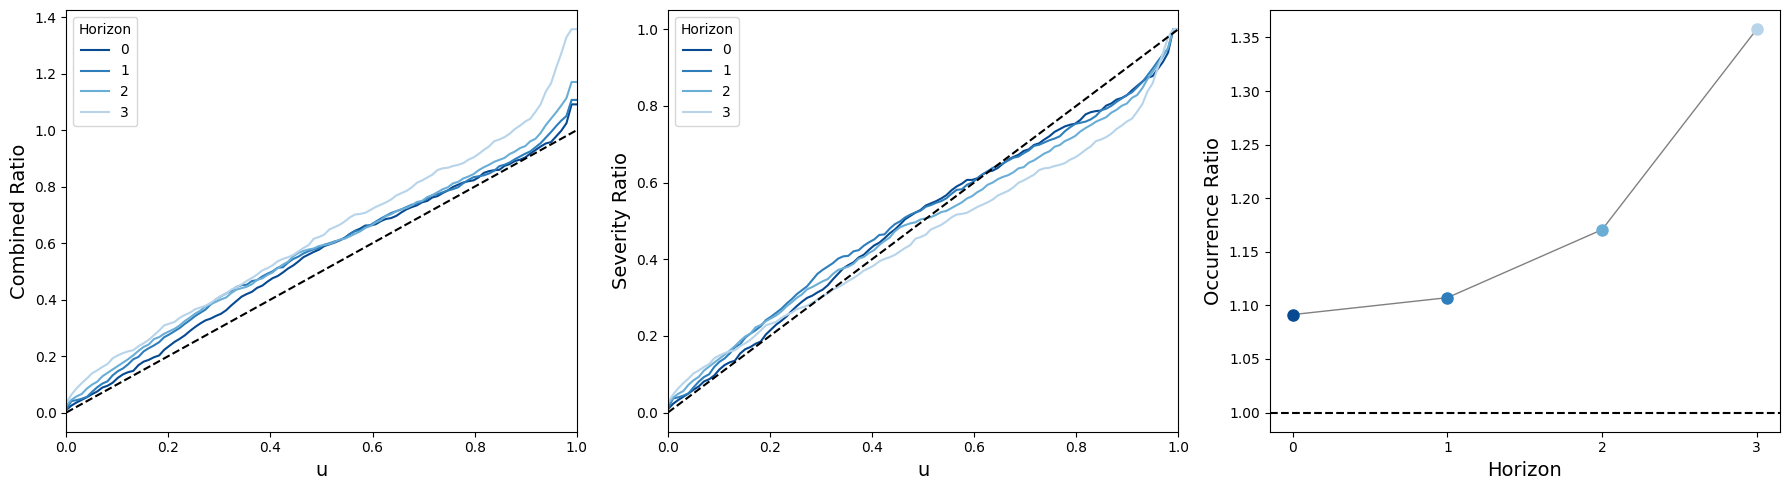

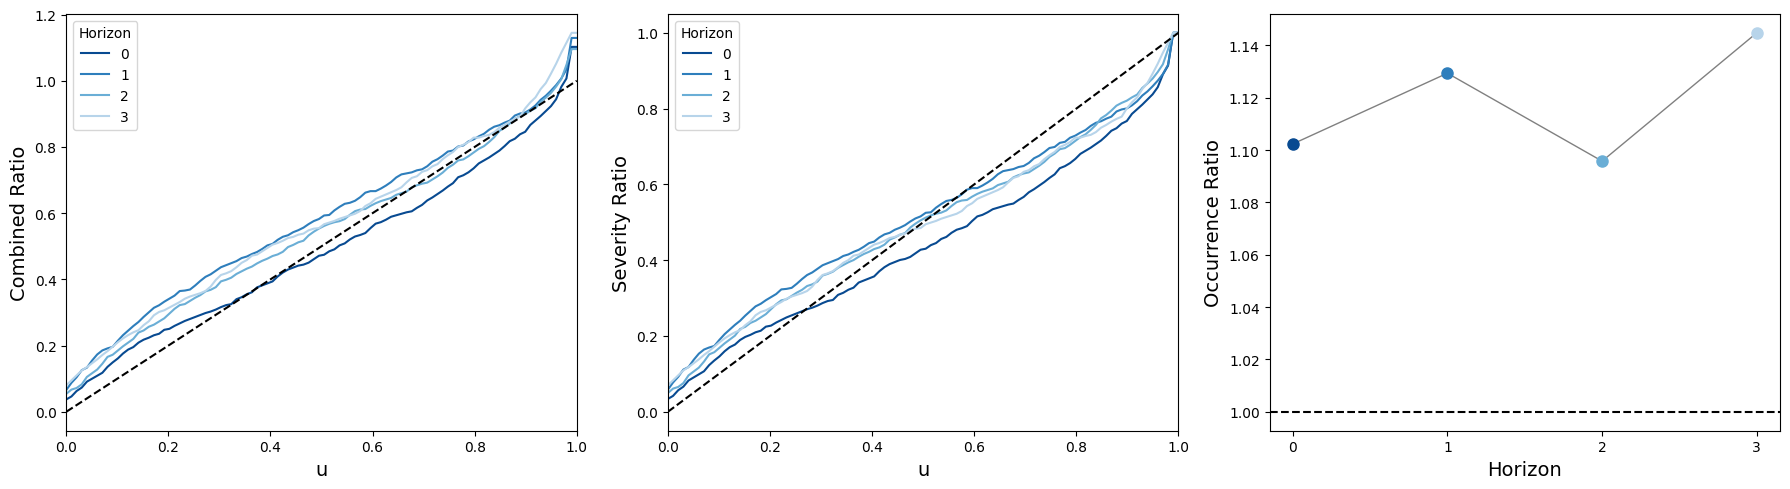

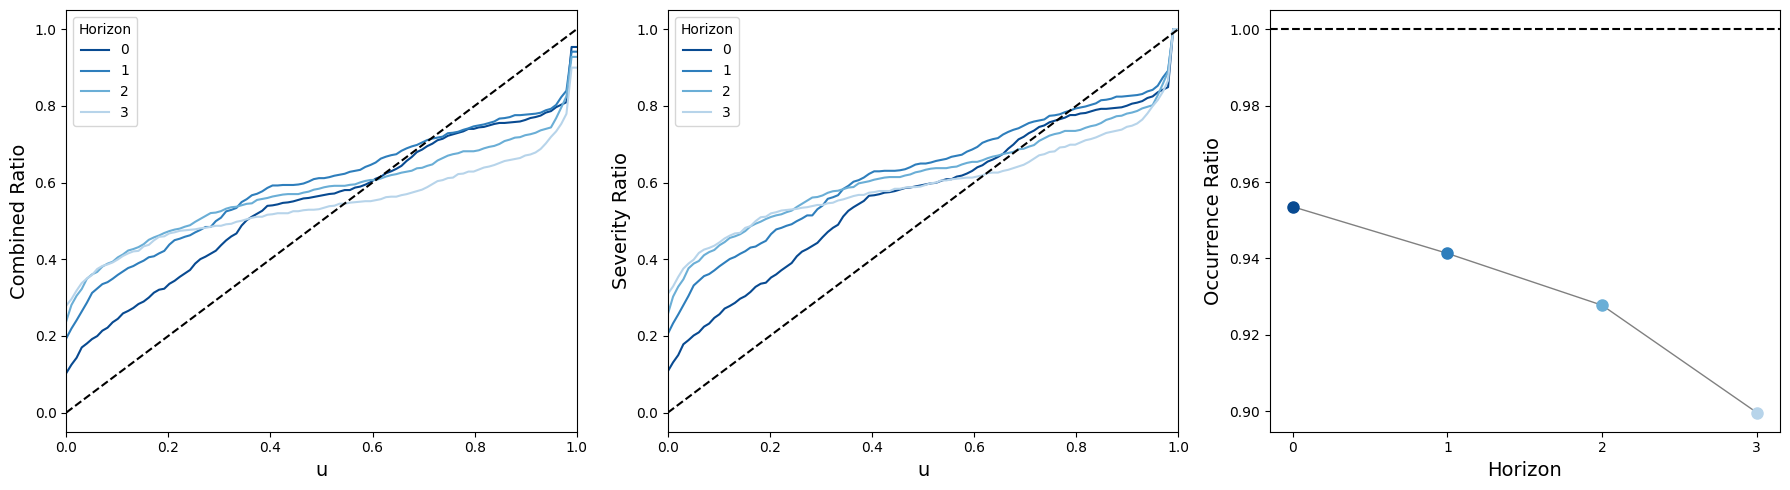

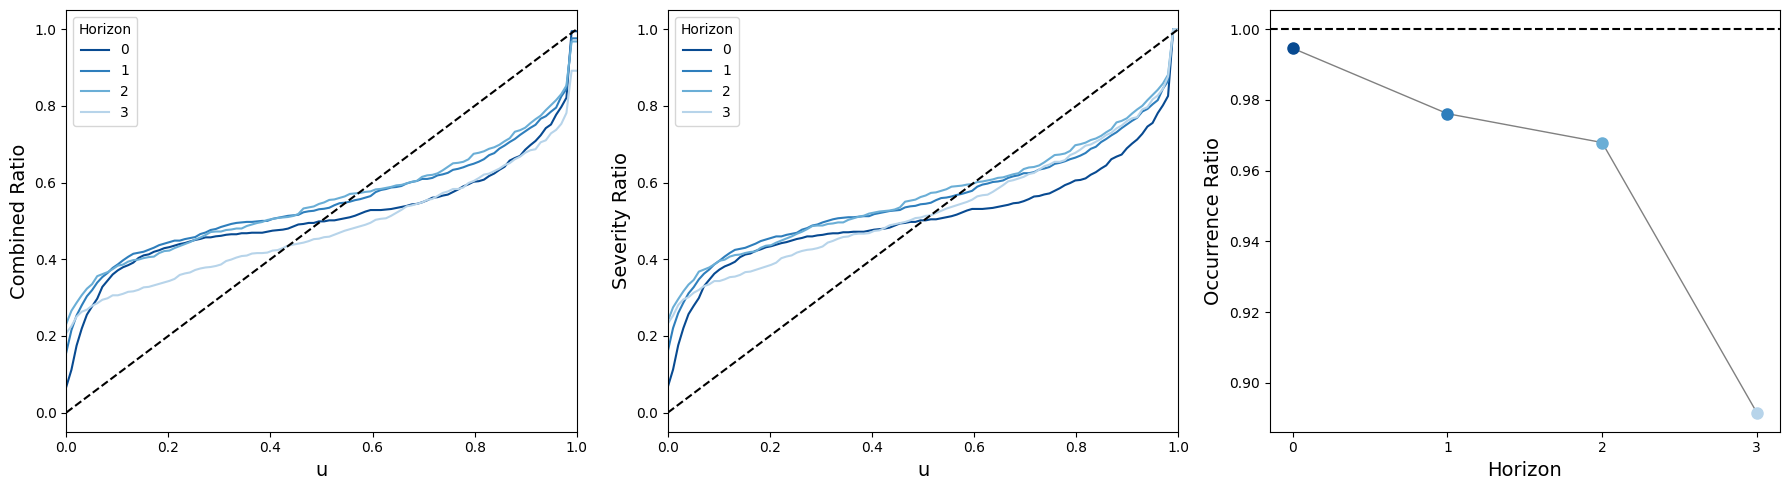

In [10]:
models = ["FluSight-ensemble", "CMU-TimeSeries", "UMass-flusion", "UM-DeepOutbreak", "FluSight-baseline"]

for model_id in models:
    horizon_maps = {
        h: tail_calibration(result[(result["horizon"] == h ) & (result['model_id'] == model_id)], "location", "observation", 75)
        for h in [0, 1, 2, 3]
    }
    fig = plot_tail_miscalibration_by_horizon(horizon_maps, percentile=75)
    fig.savefig(
                f'../images/diagnostics/supplemental/tail_calibration_{model_id}_75_by_horizon.png',
                dpi=150, bbox_inches='tight'
            )

## Tail Calibration versus WIS 

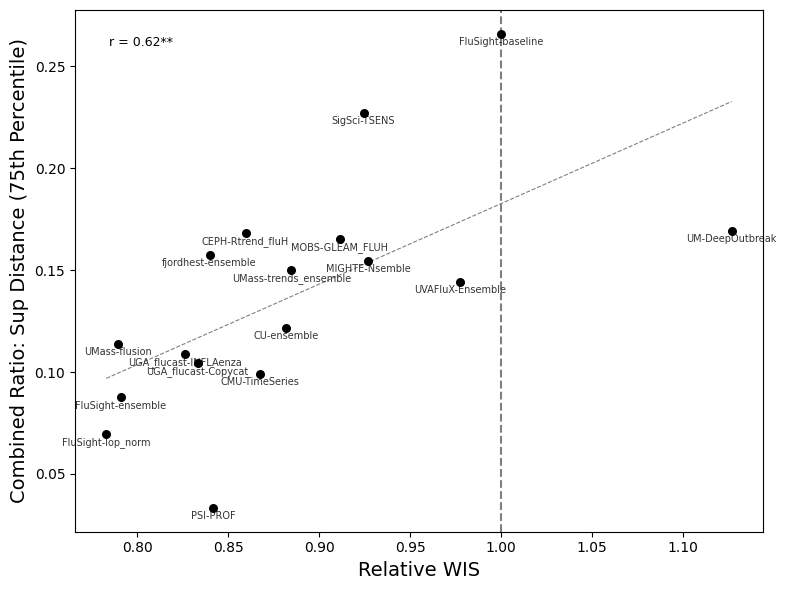

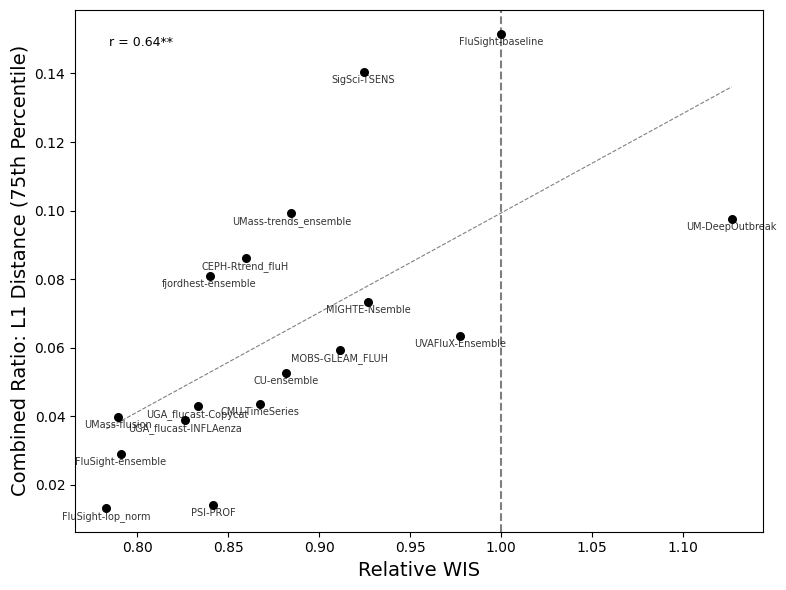

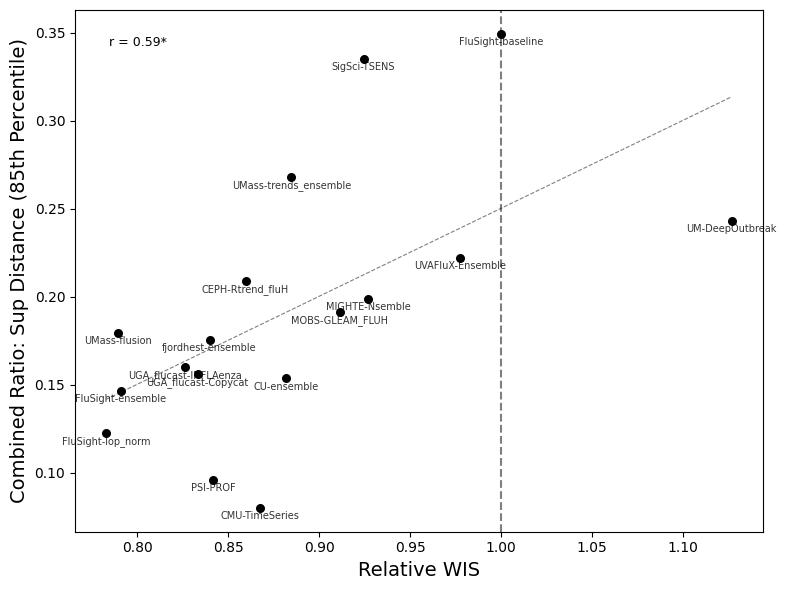

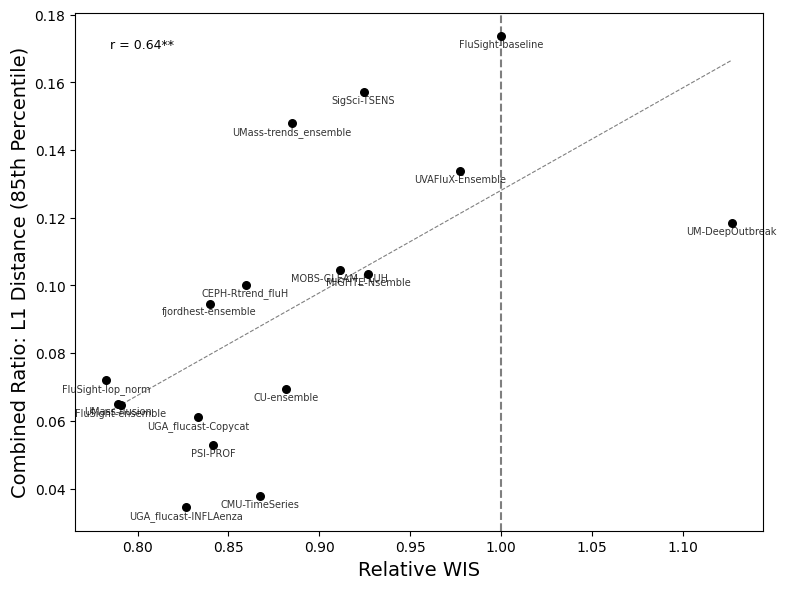

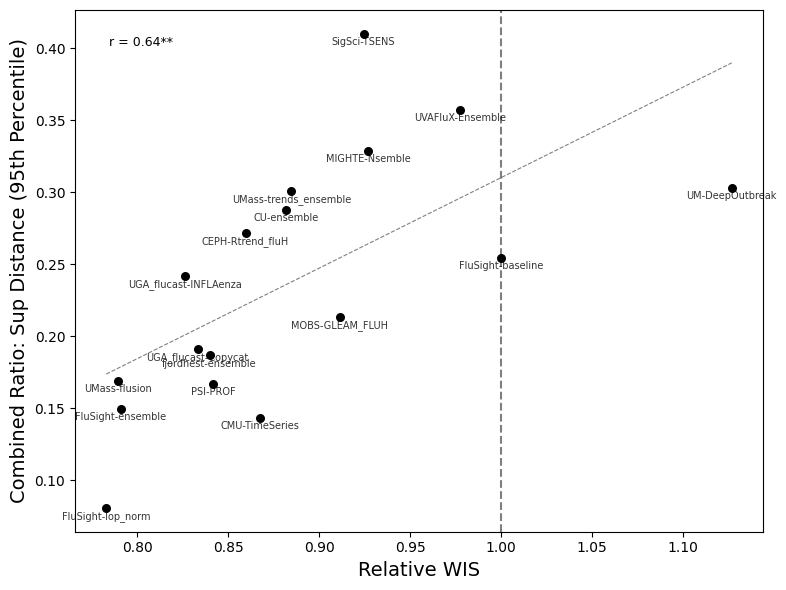

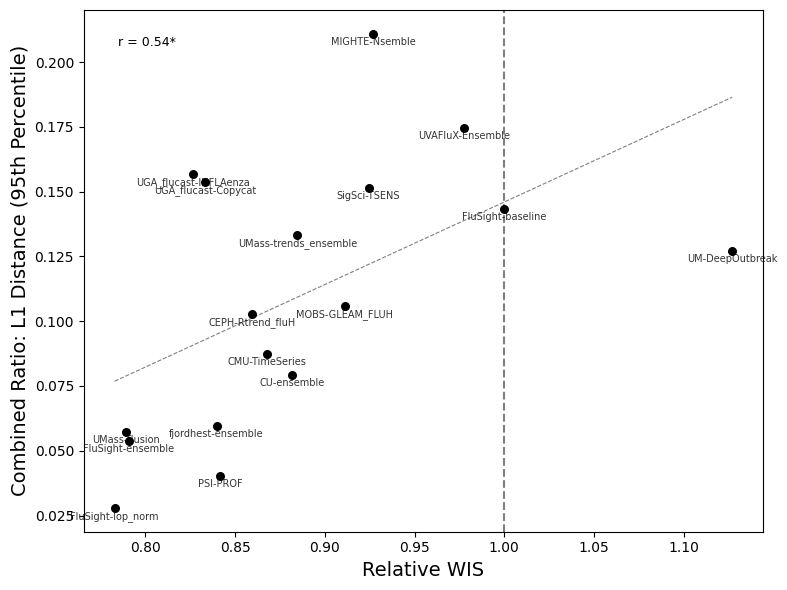

In [9]:
mask = (
    (result["target"] == "wk inc flu hosp") 
    & (result["horizon"] == 0)
    & (result["location_name"] != "US")
)
summary_df = evaluate_models(
    evaluation_df=result[mask],
    id_col="location",
    percentiles=[75, 85, 95], 
    baseline_model="FluSight-baseline")

for p in [75, 85, 95]:
    fig_sup = plot_wis_vs_tail(summary_df, metric=f"tail_sup_{p}")
    fig_sup.savefig(
                f'../images/diagnostics/supplemental/wis_vs_tail_sup_{p}.png',
                dpi=150, bbox_inches='tight'
            )
    fig_l1 = plot_wis_vs_tail(summary_df, metric=f"tail_l1_{p}")
    fig_l1.savefig(
                f'../images/diagnostics/supplemental/wis_vs_tail_l1_{p}.png',
                dpi=150, bbox_inches='tight'
            )

## How about at horizon=3?

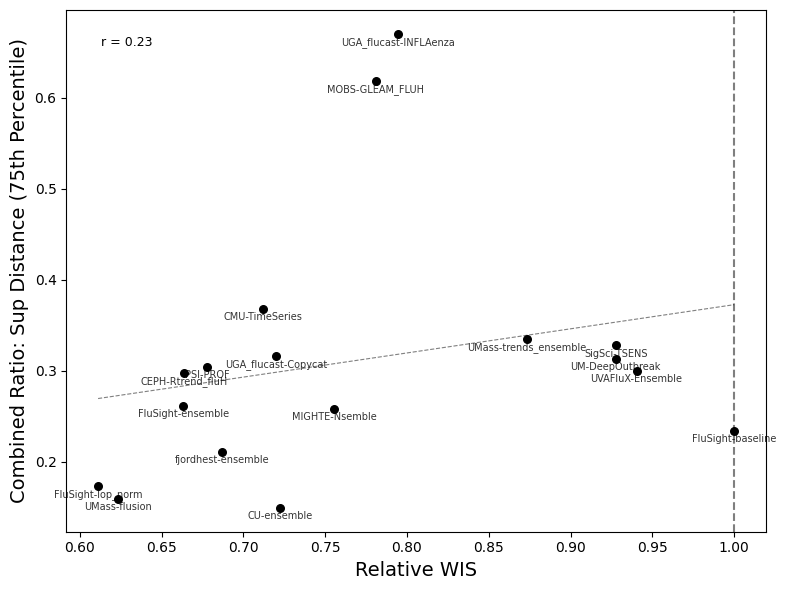

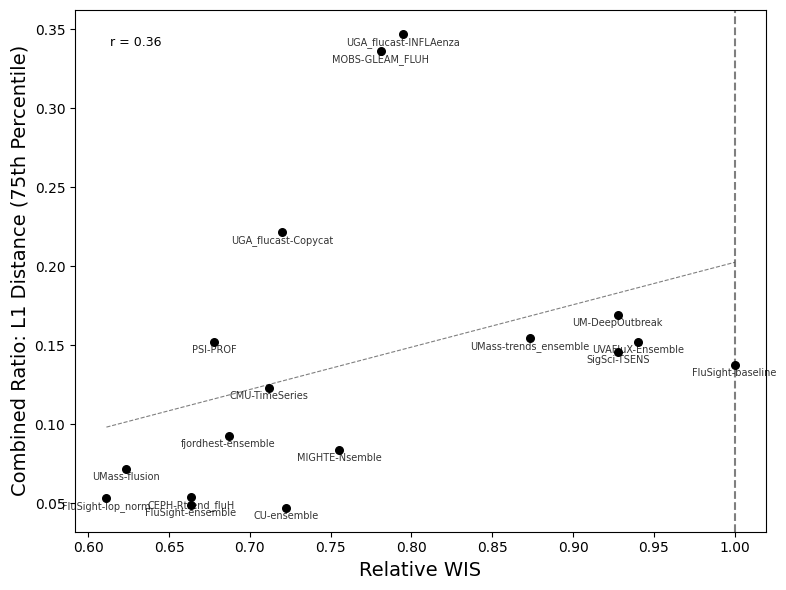

In [13]:
mask = (
    (result["target"] == "wk inc flu hosp") 
    & (result["horizon"] == 3)
    & (result["location_name"] != "US")
)
summary_df = evaluate_models(
    evaluation_df=result[mask],
    id_col="location",
    percentiles=[75], 
    baseline_model="FluSight-baseline")

for p in [75]:
    fig_sup = plot_wis_vs_tail(summary_df, metric=f"tail_sup_{p}")
    fig_sup.savefig(
                f'../images/diagnostics/supplemental/wis_vs_tail_sup_{p}_h3.png',
                dpi=150, bbox_inches='tight'
            )
    fig_l1 = plot_wis_vs_tail(summary_df, metric=f"tail_l1_{p}")
    fig_l1.savefig(
                f'../images/diagnostics/supplemental/wis_vs_tail_l1_{p}_h3.png',
                dpi=150, bbox_inches='tight'
            )